In [33]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

import os

In [2]:
''' set paths '''
save_figs = f"../figures/targeting/"

In [57]:
''' define the data
add ROS105
'''
bird_ids = ["PRL158", "IND67", "AMB88", "RBY55", "CHC77", "AMB153", 
            "ROS96", "RBY92", "AMB45", "SLV132", 
            "RBY94", "AMB154", "PRL73", "SPP134"]
bird_colors = ["w", "xkcd:royal blue", "xkcd:orange", "r", "xkcd:brown", "xkcd:burnt orange", 
               "xkcd:pink", "xkcd:crimson", "xkcd:light orange", "xkcd:grey",
               "xkcd:pale red", "xkcd:brownish orange", "xkcd:cream", "xkcd:sky"
              ]


stim_response = np.asarray([1, 2, 0, 0, 2, 0, 
                            4, 0, 1, 3,
                            2, 2, 0, 1]).astype(int)

surgery_dates = ["9.15.25", "8.26.25", "9.23.25", "7.29.25", "6.19.25", "5.27.25",
                 "6.16.25", "5.5.25", "3.20.25", "2.4.25",
                 "10.30.24", "10.22.24", "5.20.24", "5.29.24"
                ]

relative_dates = np.asarray([0,49,146,154,251,295,341,383,363,386,426,482,454, 474])
relative_dates = np.repeat(relative_dates[::-1], 2)/np.max(relative_dates)

probe_pos = np.asarray([]).astype(int)

In [61]:
len(bird_ids)

14

In [5]:
'''
AP insertion coordinates - based on estimated distance between electrodes and center coord
relative distance to LHY center - neg is P, pos is A
nan = not visible
'''
# insertion coordinates
ins_coords_ap = np.asarray([
    [1.4-0.24, 1.4+0.24], # PRL158
    [1.2-0.24, 1.2+0.24], # IND67
    [1.4-0.24, 1.4+0.24], # AMB88
    [1.4-0.2, 1.4+0.2], # RBY55
    [1.19-0.2, 1.19+0.2], # CHC77
    [1.2-0.2, 1.2+0.2], # AMB153
    [1.2-0.2, 1.2+0.2], # ROS96
    [1.2-0.2, 1.2+0.2], # RBY92
    [1.15-0.2, 1.15+0.2], # AMB45
    [1.2-0.2, 1.2+0.2], # SLV132
    [1.2-0.2, 1.2+0.2], # RBY94
    [1.2-0.2, 1.2+0.2], # AMB154
    [1.2-0.21, 1.2+0.21], # PRL73
    [1.2-0.17, 1.2+0.17], # SPP134
])

# tip position relative to estimated LHY center
lhy_coords_ap = np.asarray([
    [-0.75, 0.05], # PRL158
    [0.15, 0.45], # IND67
    [-1.05, -0.65], # AMB88
    [np.nan, -0.95], # RBY55
    [-0.35, -0.05], # CHC77
    [-0.85, -0.65], # AMB153
    [-0.25, 0.35], # ROS96
    [-0.75, -0.25], # RBY92
    [-0.35, -0.15], # AMB45
    [0.55, 0.65], # SLV132
    [-0.15, 0.35], # RBY94
    [-0.25, 0.15], # AMB154
    [-0.45, 0.15], # PRL73
    [np.nan, 0.2], # SPP134
])


# HPC width on entry slice - measured from midline to DM/DL bound at surface
hpc_width_ap = np.asarray([
    [1.86, 1.66], # PRL158
    [2.163, 1.98], # IND67
    [2.136, 1.94], # AMB88
    [1.75, 1.697], # RBY55
    [1.94, 1.80], # CHC77
    [1.78, 1.56], # AMB153
    [1.88, 1.77], # ROS96
    [1.86, 1.68], # RBY92
    [2.18, 2.03], # AMB45
    [2.05, 2.00], # SLV132
    [1.72, 1.89], # RBY94
    [np.nan, np.nan], # AMB154
    [1.98, 1.85], # PRL73
    [np.nan, 1.81], # SPP134
])

# anterior commissure relative position
# ant_com_ap = np.asarray([
    
# ])

In [6]:
'''
DV insertion coordinates
relative distance to LHY center - neg is V, pos is D
nan = not visible
'''
# insertion coordinates - not worrying about this right now
# ins_coords_ap = np.asarray([
#     [1.2-0.24, 1.2+0.24], # IND67
#     [1.4-0.24, 1.4+0.24], # AMB88
#     [1.4-0.2, 1.4+0.2], # RBY55
#     [1.19-0.2, 1.19+0.2], # CHC77
#     [1.2-0.2, 1.2+0.2], # AMB153
#     [1.2-0.2, 1.2+0.2], # ROS96
#     [1.2-0.2, 1.2+0.2], # RBY92
#     [1.15-0.2, 1.15+0.2], # AMB45
#     [1.2-0.2, 1.2+0.2], # SLV132
#     [1.2-0.2, 1.2+0.2], # RBY94
#     [1.2-0.2, 1.2+0.2], # AMB154
#     [1.2-0.21, 1.2+0.21], # PRL73
#     [1.2-0.17, 1.2+0.17], # SPP134
# ])

# tip position relative to estimated LHY center
lhy_coords_dv = np.asarray([
    [0.2, -0.3], # PRL185
    [-0.5, -1.0], # IND67
    [0, -0.5], # AMB88
    [np.nan, -0.7], # RBY55
    [-1.2, -0.6], # CHC77
    [0, 0], # AMB153
    [-0.4, -0.3], # ROS96
    [-0.2, 0.2], # RBY92
    [-0.4, -0.7], # AMB45
    [-1.5, -0.8], # SLV132
    [-0.3, -0.4], # RBY94
    [0, 0.2], # AMB154
    [0.3, 0], # PRL73
    [np.nan, -0.4], # SPP134
])



In [31]:
'''
Probe insertion coordinates
ML position relative to DM/DL boundary (positive is lateral, negative is medial)
'''
hp_coords_ml = np.asarray([
    np.nan, # PRL185
    -0.09, # IND67
    -0.06, # AMB88
    np.nan, # RBY55
    -0.02, # CHC77
    -0.02, # AMB153
    -0.07, # ROS96
    -0.28, # RBY92
    -0.3, # AMB45
    -0.24, # SLV132
    -0.21, # RBY94
    -0.11, # AMB154
    -0.35, # PRL73
    np.nan, # SPP134
])

# HPC width on entry slice - measured from midline to DM/DL bound at surface
hpc_width_probe = np.asarray([
    np.nan, # PRL158
    1.26, # IND67
    1.21, # AMB88
    np.nan, # RBY55
    0.81, # CHC77
    0.59, # AMB153
    0.89, # ROS96
    0.77, # RBY92
    1.03, # AMB45
    0.91, # SLV132
    0.83, # RBY94
    0.67, # AMB154
    1.12, # PRL73
    np.nan, # SPP134
])


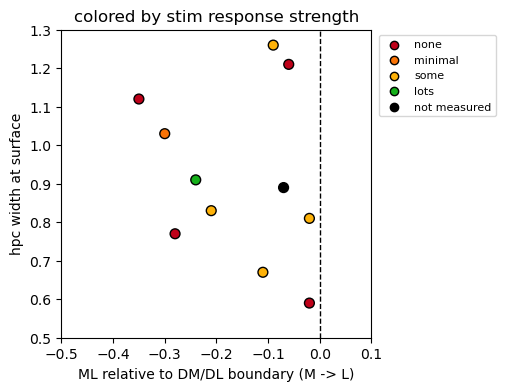

In [32]:
''' plot probe entry position vs. hpc width - colored by stim response strength '''
# fig params
dot_size = 50
bird_line_width = 1
lhy_line_width = 1
stim_colors = ["xkcd:scarlet", "xkcd:orange", "xkcd:saffron", "xkcd:green", "k"]
stim_response_colors = []
for i in stim_response:
    stim_response_colors.append(stim_colors[i])

f, ax = plt.subplots(1, 1, figsize=(4, 4))

# plot the data
ax.scatter(hp_coords_ml, hpc_width_probe,
           s=dot_size,
           facecolors=stim_response_colors,
           edgecolors='k',
           zorder=2
          )
    
# set up legend
stim_labels = ["none", "minimal", "some", "lots", "not measured"]
for c, l in zip(stim_colors, stim_labels):
    ax.scatter(5, 5, facecolors=c, edgecolors='k', label=l)
plt.legend(bbox_to_anchor=(1, 1, 0.42, 0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-0.5, 0.2, 0.1))
ax.set_yticks(np.arange(0.5, 1.4, 0.1))
ax.set_xlim([-0.5, 0.1])
ax.set_ylim([0.5, 1.3])

# DM/DL boundary
ylim = ax.get_ylim()
ax.vlines(0, ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=lhy_line_width, zorder=0)
ax.set_ylim(ylim)

# labels
ax.set_ylabel('hpc width at surface')
ax.set_xlabel('ML relative to DM/DL boundary (M -> L)')
ax.set_title('colored by stim response strength')

plt.show()
f.savefig(f'{save_figs}probe_ml_vs_response.png', dpi=600, bbox_inches='tight')

C:\Users\ilow1\AppData\Local\Temp\ipykernel_29536\1937813429.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis')


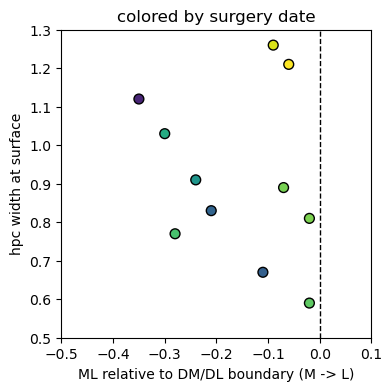

In [39]:
''' plot probe entry position vs. hpc width - colored by stim response strength '''
# fig params
dot_size = 50
bird_line_width = 1
lhy_line_width = 1
cmap = get_cmap('viridis')
surgery_date_colors = cmap(relative_dates[::2])

f, ax = plt.subplots(1, 1, figsize=(4, 4))

# plot the data
ax.scatter(hp_coords_ml, hpc_width_probe,
           s=dot_size,
           facecolors=surgery_date_colors,
           edgecolors='k',
           zorder=2
          )
    
# set up legend
# stim_labels = ["none", "minimal", "some", "lots", "not measured"]
# for c, l in zip(stim_colors, stim_labels):
#     ax.scatter(5, 5, facecolors=c, edgecolors='k', label=l)
# plt.legend(bbox_to_anchor=(1, 1, 0.42, 0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-0.5, 0.2, 0.1))
ax.set_yticks(np.arange(0.5, 1.4, 0.1))
ax.set_xlim([-0.5, 0.1])
ax.set_ylim([0.5, 1.3])

# DM/DL boundary
ylim = ax.get_ylim()
ax.vlines(0, ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=lhy_line_width, zorder=0)
ax.set_ylim(ylim)

# labels
ax.set_ylabel('hpc width at surface')
ax.set_xlabel('ML relative to DM/DL boundary (M -> L)')
ax.set_title('colored by surgery date')

plt.show()
f.savefig(f'{save_figs}probe_ml_vs_date.png', dpi=600, bbox_inches='tight')

C:\Users\ilow1\AppData\Local\Temp\ipykernel_29536\1784379044.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis')
C:\Users\ilow1\AppData\Local\Temp\ipykernel_29536\1784379044.py:12: RuntimeWarning: Mean of empty slice
  hpc_width_stim = np.nanmean(hpc_width_ap, axis=1)


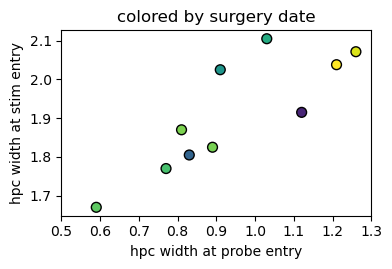

In [42]:
''' hpc width at probe entry vs. stim entry colored by surgery date '''
# fig params
dot_size = 50
bird_line_width = 1
lhy_line_width = 1
cmap = get_cmap('viridis')
surgery_date_colors = cmap(relative_dates[::2])

f, ax = plt.subplots(1, 1, figsize=(4, 4))

# data params
hpc_width_stim = np.nanmean(hpc_width_ap, axis=1)

# plot the data
ax.scatter(hpc_width_probe, hpc_width_stim,
           s=dot_size,
           facecolors=surgery_date_colors,
           edgecolors='k',
           zorder=2
          )
    
# ticks and lims
ax.set_xticks(np.arange(0.5, 1.4, 0.1))
ax.set_xlim([0.5, 1.3])
ax.set_aspect('equal')

# labels
ax.set_xlabel('hpc width at probe entry')
ax.set_ylabel('hpc width at stim entry')
ax.set_title('colored by surgery date')

plt.show()
f.savefig(f'{save_figs}probe_stim_hpc_width.png', dpi=600, bbox_inches='tight')

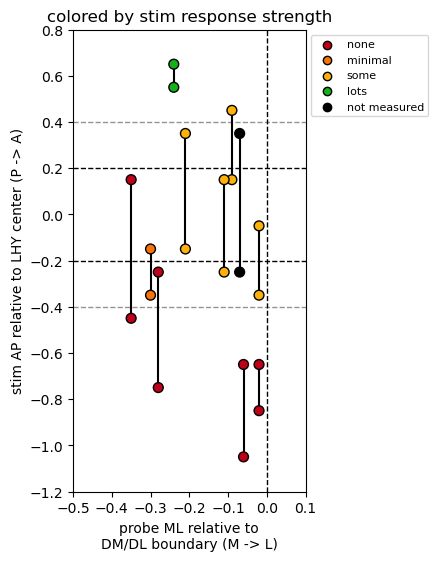

In [52]:
''' plot stim tip positions vs. probe position colored by stim response '''
# fig params
dot_size = 50
bird_line_width = 1.5
bound_line_width = 1
stim_colors = ["xkcd:scarlet", "xkcd:orange", "xkcd:saffron", "xkcd:green", "k"]
stim_response_colors = []
for i in stim_response:
    stim_response_colors.append(stim_colors[i])

f, ax = plt.subplots(1, 1, figsize=(3, 6))

# plot the data
ax.scatter(hp_coords_ml, lhy_coords_ap[:, 0],
           s=dot_size,
           facecolors=stim_response_colors,
           edgecolors='k',
           zorder=2
          )
ax.scatter(hp_coords_ml, lhy_coords_ap[:, 1],
           s=dot_size,
           facecolors=stim_response_colors,
           edgecolors='k',
           zorder=2
          )
for bird in range(len(bird_ids)):
    ax.vlines(hp_coords_ml[bird],
              lhy_coords_ap[bird, 0],
              lhy_coords_ap[bird, 1],
              colors='k', lw=bird_line_width, zorder=1)
    
# set up legend
labels = ["none", "minimal", "some", "lots", "not measured"]
for c, l in zip(stim_colors, labels):
    ax.scatter(5, 5, facecolors=c, edgecolors='k', label=l)
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-0.5, 0.2, 0.1))
ax.set_yticks(np.arange(-1.2, 1, 0.2))
ax.set_xlim([-0.5, 0.1])
ax.set_ylim([-1.2, 0.8])

# region boundaries
ylim = ax.get_ylim()
xlim = ax.get_xlim()

ax.hlines([-0.2, 0.2], xlim[0], xlim[1], 
          colors='k', linestyles='dashed', 
          lw=bound_line_width, zorder=0)
ax.hlines([-0.4, 0.4], xlim[0], xlim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=bound_line_width, zorder=0)
ax.set_xlim(xlim)

ax.vlines(0, ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=bound_line_width, zorder=0)
ax.set_ylim(ylim)
# ax.set_aspect('equal')

# labels
ax.set_ylabel('stim AP relative to LHY center (P -> A)')
ax.set_xlabel('probe ML relative to\nDM/DL boundary (M -> L)')
ax.set_title('colored by stim response strength')

plt.show()
f.savefig(f'{save_figs}stim_probe_loc_vs_response.png', dpi=600, bbox_inches='tight')

C:\Users\ilow1\anaconda3\Lib\site-packages\matplotlib\axes\_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


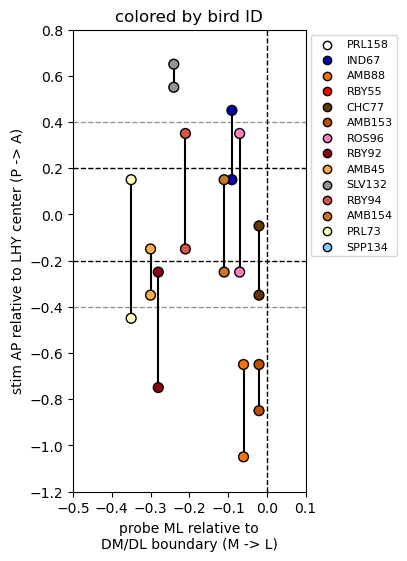

In [58]:
''' plot stim tip positions vs. probe position colored by bird '''
# fig params
dot_size = 50
bird_line_width = 1.5
bound_line_width = 1
f, ax = plt.subplots(1, 1, figsize=(3, 6))

# plot the data
ax.scatter(hp_coords_ml, lhy_coords_ap[:, 0],
           s=dot_size,
           facecolors=bird_colors,
           edgecolors='k',
           zorder=2
          )
ax.scatter(hp_coords_ml, lhy_coords_ap[:, 1],
           s=dot_size,
           facecolors=bird_colors,
           edgecolors='k',
           zorder=2
          )
for bird in range(len(bird_ids)):
    ax.vlines(hp_coords_ml[bird],
              lhy_coords_ap[bird, 0],
              lhy_coords_ap[bird, 1],
              colors='k', lw=bird_line_width, zorder=1)
    
# set up legend
for c, l in zip(bird_colors, bird_ids):
    ax.scatter(5, 5, facecolors=c, edgecolors='k', label=l)
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-0.5, 0.2, 0.1))
ax.set_yticks(np.arange(-1.2, 1, 0.2))
ax.set_xlim([-0.5, 0.1])
ax.set_ylim([-1.2, 0.8])

# region boundaries
ylim = ax.get_ylim()
xlim = ax.get_xlim()

ax.hlines([-0.2, 0.2], xlim[0], xlim[1], 
          colors='k', linestyles='dashed', 
          lw=bound_line_width, zorder=0)
ax.hlines([-0.4, 0.4], xlim[0], xlim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=bound_line_width, zorder=0)
ax.set_xlim(xlim)

ax.vlines(0, ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=bound_line_width, zorder=0)
ax.set_ylim(ylim)
# ax.set_aspect('equal')

# labels
ax.set_ylabel('stim AP relative to LHY center (P -> A)')
ax.set_xlabel('probe ML relative to\nDM/DL boundary (M -> L)')
ax.set_title('colored by bird ID')

plt.show()
f.savefig(f'{save_figs}stim_probe_loc_by_bird.png', dpi=600, bbox_inches='tight')

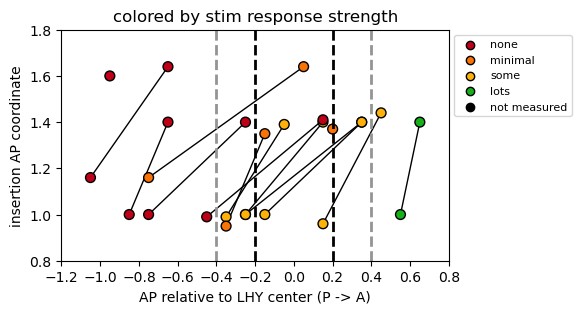

In [7]:
''' plot insertion coordinates and relative tip position colored by stim response '''
# fig params
dot_size = 50
line_width = 1
stim_colors = ["xkcd:scarlet", "xkcd:orange", "xkcd:saffron", "xkcd:green", "k"]
stim_response_colors = []
for i in stim_response:
    stim_response_colors.append(stim_colors[i])
    stim_response_colors.append(stim_colors[i])

f, ax = plt.subplots(1, 1, figsize=(5, 3))

# plot the data
ax.scatter(np.ravel(lhy_coords_ap), np.ravel(ins_coords_ap),
           s=dot_size,
           facecolors=stim_response_colors,
           edgecolors='k',
           zorder=1
          )
for bird in range(len(bird_ids)):
    ax.plot(lhy_coords_ap[bird], ins_coords_ap[bird],
            '-k', lw=line_width, zorder=0)
    
# set up legend
labels = ["none", "minimal", "some", "lots", "not measured"]
for c, l in zip(stim_colors, labels):
    ax.scatter(5, 5, facecolors=c, edgecolors='k', label=l)
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-1.4, 1, 0.2))
ax.set_yticks(np.arange(0.8, 2, 0.2))
ax.set_ylim([0.8, 1.8])
ax.set_xlim([-1.2, 0.8])

# LHY bounds
ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.vlines([-0.4, 0.4], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

# labels
ax.set_ylabel('insertion AP coordinate')
ax.set_xlabel('AP relative to LHY center (P -> A)')
ax.set_title('colored by stim response strength')

plt.show()
f.savefig(f'{save_figs}stim_ap_vs_response.png', dpi=600, bbox_inches='tight')

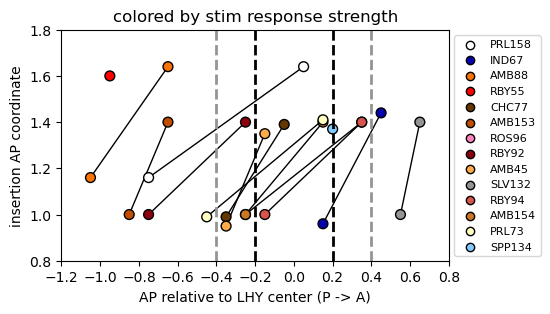

In [60]:
''' plot insertion coordinates and relative tip position colored by stim response '''
# fig params
dot_size = 50
line_width = 1
bird_colors_dbl = []
n_birds = len(bird_colors)
for i in range(n_birds):
    bird_colors_dbl.append(bird_colors[i])
    bird_colors_dbl.append(bird_colors[i])

f, ax = plt.subplots(1, 1, figsize=(5, 3))

# plot the data
ax.scatter(np.ravel(lhy_coords_ap), np.ravel(ins_coords_ap),
           s=dot_size,
           facecolors=bird_colors_dbl,
           edgecolors='k',
           zorder=1
          )
for bird in range(len(bird_ids)):
    ax.plot(lhy_coords_ap[bird], ins_coords_ap[bird],
            '-k', lw=line_width, zorder=0)
    
# set up legend
for c, l in zip(bird_colors, bird_ids):
    ax.scatter(5, 5, facecolors=c, edgecolors='k', label=l)
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-1.4, 1, 0.2))
ax.set_yticks(np.arange(0.8, 2, 0.2))
ax.set_ylim([0.8, 1.8])
ax.set_xlim([-1.2, 0.8])

# LHY bounds
ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.vlines([-0.4, 0.4], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

# labels
ax.set_ylabel('insertion AP coordinate')
ax.set_xlabel('AP relative to LHY center (P -> A)')
ax.set_title('colored by stim response strength')

plt.show()
f.savefig(f'{save_figs}stim_ap_by_bird.png', dpi=600, bbox_inches='tight')

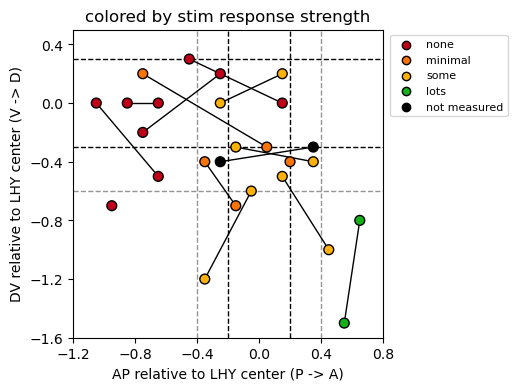

In [8]:
''' plot tip position DV vs. AP '''
# fig params
dot_size = 50
bird_line_width = 1
lhy_line_width = 1
stim_colors = ["xkcd:scarlet", "xkcd:orange", "xkcd:saffron", "xkcd:green", "k"]
stim_response_colors = []
for i in stim_response:
    stim_response_colors.append(stim_colors[i])
    stim_response_colors.append(stim_colors[i])

f, ax = plt.subplots(1, 1, figsize=(4, 4))

# plot the data
ax.scatter(np.ravel(lhy_coords_ap), np.ravel(lhy_coords_dv),
           s=dot_size,
           facecolors=stim_response_colors,
           edgecolors='k',
           zorder=2
          )
for bird in range(len(bird_ids)):
    ax.plot(lhy_coords_ap[bird], lhy_coords_dv[bird],
            '-k', lw=line_width, zorder=1)
    
# set up legend
labels = ["none", "minimal", "some", "lots", "not measured"]
for c, l in zip(stim_colors, labels):
    ax.scatter(5, 5, facecolors=c, edgecolors='k', label=l)
plt.legend(bbox_to_anchor=(1, 1, 0.42, 0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-1.2, 1, 0.4))
ax.set_yticks(np.arange(-1.6, 0.5, 0.4))
ax.set_ylim([-1.6, 0.5])
ax.set_xlim([-1.2, 0.8])

# LHY bounds
ylim = ax.get_ylim()
xlim = ax.get_xlim()

ax.hlines([-0.3, 0.3], xlim[0], xlim[1], 
          colors='k', linestyles='dashed', 
          lw=lhy_line_width, zorder=0)
ax.hlines([-0.6, 0.6], xlim[0], xlim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=lhy_line_width, zorder=0)
ax.set_xlim(xlim)

ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=lhy_line_width, zorder=0)
ax.vlines([-0.4, 0.4], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=lhy_line_width, zorder=0)
ax.set_ylim(ylim)

# labels
ax.set_ylabel('DV relative to LHY center (V -> D)')
ax.set_xlabel('AP relative to LHY center (P -> A)')
ax.set_title('colored by stim response strength')

plt.show()
f.savefig(f'{save_figs}stim_ap_dv_vs_response.png', dpi=600, bbox_inches='tight')

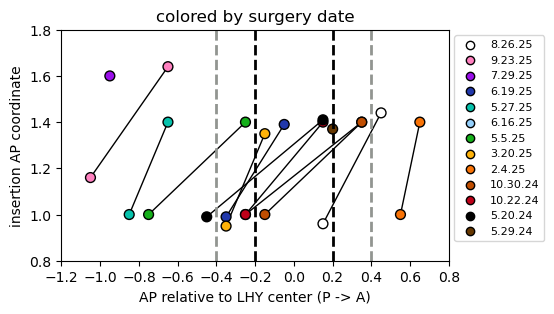

In [44]:
''' plot insertion coordinates and relative tip position colored by surgery date '''
from matplotlib.cm import get_cmap

# fig params
dot_size = 50
line_width = 1
date_colors = ["w", "xkcd:pink", "xkcd:violet", "xkcd:sapphire",
               'xkcd:turquoise', 'xkcd:light blue', "xkcd:green", "xkcd:saffron",
               "xkcd:orange", 'xkcd:burnt orange', "xkcd:scarlet", "k", "xkcd:brown"]
surgery_date_colors = []
for i in range(len(date_colors)):
    surgery_date_colors.append(date_colors[i])
    surgery_date_colors.append(date_colors[i])

f, ax = plt.subplots(1, 1, figsize=(5, 3))

# plot the data
ax.scatter(np.ravel(lhy_coords_ap), np.ravel(ins_coords_ap),
           s=dot_size,
           facecolors=surgery_date_colors,
           edgecolors='k',
           zorder=1
          )
for bird in range(len(bird_ids)):
    ax.plot(lhy_coords_ap[bird], ins_coords_ap[bird],
            '-k', lw=line_width, zorder=0)
    
# set up legend
labels = surgery_dates
for c, l in zip(date_colors, labels):
    ax.scatter(5, 5, facecolors=c, edgecolors='k', label=l)
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-1.4, 1, 0.2))
ax.set_yticks(np.arange(0.8, 2, 0.2))
ax.set_ylim([0.8, 1.8])
ax.set_xlim([-1.2, 0.8])

# LHY bounds
ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.vlines([-0.4, 0.4], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

# labels
ax.set_ylabel('insertion AP coordinate')
ax.set_xlabel('AP relative to LHY center (P -> A)')
ax.set_title('colored by surgery date')

plt.show()
f.savefig(f'{save_figs}stim_ap_vs_date.png', dpi=600, bbox_inches='tight')

C:\Users\ilow1\AppData\Local\Temp\ipykernel_29536\1477569789.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis')


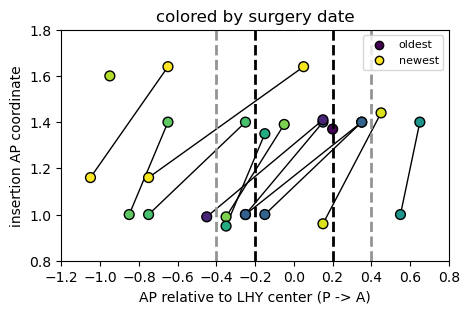

In [9]:
''' plot insertion coordinates and relative tip position colored by surgery date '''

# fig params
dot_size = 50
line_width = 1
labels = bird_ids
cmap = get_cmap('viridis')
surgery_date_colors = cmap(relative_dates)

f, ax = plt.subplots(1, 1, figsize=(5, 3))

# plot the data
ax.scatter(np.ravel(lhy_coords_ap), np.ravel(ins_coords_ap),
           s=dot_size,
           facecolors=surgery_date_colors,
           edgecolors='k',
           zorder=1
          )
for bird in range(len(bird_ids)):
    ax.plot(lhy_coords_ap[bird], ins_coords_ap[bird],
            '-k', lw=line_width, zorder=0)
    
# set up legend
ax.scatter(5, 5, 
           facecolors=surgery_date_colors[np.argmin(relative_dates)], 
           edgecolors='k', label='oldest')
ax.scatter(5, 5,
           facecolors=surgery_date_colors[np.argmax(relative_dates)], 
           edgecolors='k', label='newest')
plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)
    
# ticks and lims
ax.set_xticks(np.arange(-1.4, 1, 0.2))
ax.set_yticks(np.arange(0.8, 2, 0.2))
ax.set_ylim([0.8, 1.8])
ax.set_xlim([-1.2, 0.8])

# LHY bounds
ylim = ax.get_ylim()
ax.vlines([-0.2, 0.2], ylim[0], ylim[1], 
          colors='k', linestyles='dashed', 
          lw=2, zorder=2)
ax.vlines([-0.4, 0.4], ylim[0], ylim[1], 
          colors='xkcd:gray', linestyles='dashed', 
          lw=2, zorder=2)
ax.set_ylim(ylim)

# labels
ax.set_ylabel('insertion AP coordinate')
ax.set_xlabel('AP relative to LHY center (P -> A)')
ax.set_title('colored by surgery date')

plt.show()
f.savefig(f'{save_figs}stim_ap_vs_date.png', dpi=600, bbox_inches='tight')

Text(0.5, 0, 'relative date')

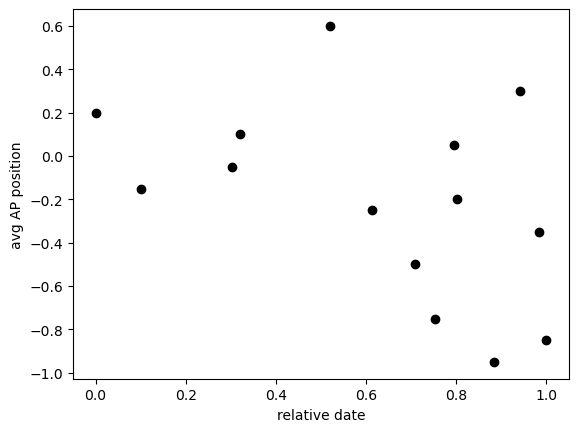

In [11]:
plt.scatter(relative_dates[::2], np.nanmean(lhy_coords_ap, axis=1), c='k')
plt.ylabel('avg AP position')
plt.xlabel('relative date')

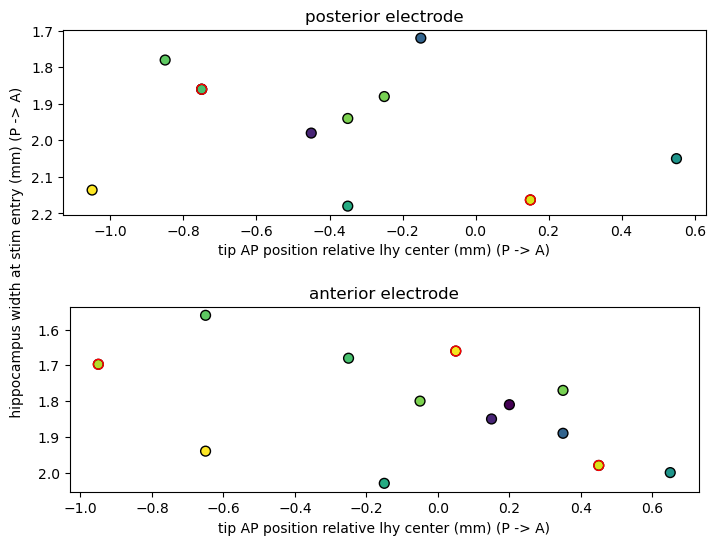

In [13]:
''' stim entry vs. tip position '''
f, ax = plt.subplots(2, 1, figsize=(12, 6),
                         gridspec_kw=dict(hspace=0.5))

# posterior electrode
ax[0].scatter(lhy_coords_ap[:, 0], hpc_width_ap[:, 0], 
            s=dot_size,
           facecolors=surgery_date_colors[::2],
           edgecolors='k', zorder=0)
ax[0].scatter(lhy_coords_ap[[0, 1, 3], 0], hpc_width_ap[[0, 1, 3], 0], 
            s=dot_size,
           facecolors='none',
           edgecolors='r', zorder=1)

# set up legend
# labels = bird_ids
# for c, l in zip(surgery_date_colors[::2], labels):
#     ax[0].scatter(5, 5, facecolors=c, edgecolors='k', label=l)
# plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)

ax[0].set_ylim(ax[0].get_ylim()[::-1])
ax[0].set_aspect('equal')
ax[0].set_xlabel('tip AP position relative lhy center (mm) (P -> A)')
ax[0].set_title('posterior electrode')


# anterior electrode
ax[1].scatter(lhy_coords_ap[:, 1], hpc_width_ap[:, 1], 
            s=dot_size,
           facecolors=surgery_date_colors[::2],
           edgecolors='k')
ax[1].scatter(lhy_coords_ap[[0, 1, 3], 1], hpc_width_ap[[0, 1, 3], 1], 
            s=dot_size,
           facecolors='none',
           edgecolors='r', zorder=1)

ax[1].set_ylim(ax[1].get_ylim()[::-1])
ax[1].set_aspect('equal')
ax[1].set_xlabel('tip AP position relative lhy center (mm) (P -> A)')
ax[1].set_ylabel('                 hippocampus width at stim entry (mm) (P -> A)', 
                 loc='bottom', labelpad=10)
ax[1].set_title('anterior electrode')
plt.show()

f.savefig(f'{save_figs}entry_vs_tip.png', dpi=600, bbox_inches='tight')

In [14]:
bird_ids

['PRL158',
 'IND67',
 'AMB88',
 'RBY55',
 'CHC77',
 'AMB153',
 'ROS96',
 'RBY92',
 'AMB45',
 'SLV132',
 'RBY94',
 'AMB154',
 'PRL73',
 'SPP134']

In [143]:
avg_ap = np.nanmean(lhy_coords_ap, axis=1)
std_mm = stats.tstd(avg_ap)

print(f'standard deviation tip position = {np.round(std_mm, 3)*1000} um')

standard deviation tip position = 466.0 um


In [145]:
avg_ap = np.nanmean(hpc_width_ap, axis=1)
avg_ap = avg_ap[~np.isnan(avg_ap)]
std_mm = stats.tstd(avg_ap)

print(f'standard deviation entry position = {np.round(std_mm, 3)*1000} um')

standard deviation entry position = 144.0 um


C:\Users\ilow1\AppData\Local\Temp\ipykernel_22332\267203931.py:1: RuntimeWarning: Mean of empty slice
  avg_ap = np.nanmean(hpc_width_ap, axis=1)


In [132]:
avg_ap

array([2.0715, 2.038 , 1.7235, 1.87  , 1.67  , 1.825 , 1.77  , 2.105 ,
       2.025 , 1.805 ,    nan, 1.915 , 1.81  ])